In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/predict-housing-price/estate_train.csv
/kaggle/input/competitions/predict-housing-price/estate_sample_submission.csv
/kaggle/input/competitions/predict-housing-price/estate_test.csv


# Importing Libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import KFold, ParameterSampler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error

from xgboost import XGBRegressor

# Load data

In [3]:
# -----------------------------
# 1) Load data
# -----------------------------
train_path = "/kaggle/input/competitions/predict-housing-price/estate_train.csv"
test_path  = "/kaggle/input/competitions/predict-housing-price/estate_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

TARGET = "TargetPrice"
ID_COL = "PropertyID"

X_raw = train_df.drop(columns=[TARGET, ID_COL]).copy()
y = train_df[TARGET].copy()

X_test_raw = test_df.drop(columns=[ID_COL]).copy()
test_ids = test_df[ID_COL].copy()

In [4]:
train_df.head()

,IncomeLevel,PropertyAge,TotalRooms,TotalBedrooms,NeighborhoodPop,AvgOccupancy,Latitude,Longitude,TargetPrice,PropertyID,RoomsPerHousehold,BedroomsRatio
0,3.287977,32.970198,5.128150,0.990769,2339.474039,3.739113,32.71,-117.03,1.030,PROP_14196,1.359130,0.200576
1,3.804601,49.030192,4.372696,1.040469,1269.383596,1.429576,33.77,-118.16,3.821,PROP_08267,2.573820,0.232703
2,4.193302,NaN,5.718626,0.989809,865.436104,2.481219,34.66,-120.48,1.726,PROP_17445,2.073224,0.174486
3,2.029509,36.255617,4.131418,1.032285,1455.381923,3.914447,32.69,-117.11,0.934,PROP_14265,1.002116,0.258269
4,3.540823,42.918534,6.270531,1.147146,895.050628,2.681969,36.78,-119.80,0.965,PROP_02271,2.725400,0.180940


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   IncomeLevel        16512 non-null  float64
 1   PropertyAge        15199 non-null  float64
 2   TotalRooms         16512 non-null  float64
 3   TotalBedrooms      16512 non-null  float64
 4   NeighborhoodPop    16512 non-null  float64
 5   AvgOccupancy       16512 non-null  float64
 6   Latitude           16512 non-null  float64
 7   Longitude          16512 non-null  float64
 8   TargetPrice        16512 non-null  float64
 9   PropertyID         16512 non-null  object 
 10  RoomsPerHousehold  16512 non-null  float64
 11  BedroomsRatio      16512 non-null  float64
dtypes: float64(11), object(1)
memory usage: 1.5+ MB


In [6]:
train_df.isna().sum()

IncomeLevel             0
PropertyAge          1313
TotalRooms              0
TotalBedrooms           0
NeighborhoodPop         0
AvgOccupancy            0
Latitude                0
Longitude               0
TargetPrice             0
PropertyID              0
RoomsPerHousehold       0
BedroomsRatio           0
dtype: int64

In [7]:
train_df.describe()

,IncomeLevel,PropertyAge,TotalRooms,TotalBedrooms,NeighborhoodPop,AvgOccupancy,Latitude,Longitude,TargetPrice,RoomsPerHousehold,BedroomsRatio
count,16512.000000,15199.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,3.880870,28.610537,5.435311,1.096797,1426.441888,3.097123,35.643149,-119.582290,2.071947,1.980582,0.212858
std,1.906229,12.604955,2.387346,0.433573,1137.594296,11.589701,2.136665,2.005654,1.156226,1.125818,0.057995
min,0.409295,0.567139,0.973695,0.329765,-44.578990,0.579087,32.550000,-124.350000,0.149990,0.002547,0.100000
25%,2.564153,18.195306,4.450483,1.005528,788.555955,2.362349,33.930000,-121.810000,1.198000,1.526243,0.175178
50%,3.544769,28.747429,5.238836,1.049505,1169.707835,2.835532,34.260000,-118.510000,1.798500,1.941541,0.202808
75%,4.779065,37.045296,6.064049,1.102542,1730.584980,3.364962,37.720000,-118.010000,2.651250,2.300615,0.239501
max,15.113356,53.490497,141.875493,25.630214,35739.248210,1243.662159,41.950000,-114.310000,5.000010,52.033333,1.000000


# EDA
## Histogram 
- Visualizing the distribution of all features

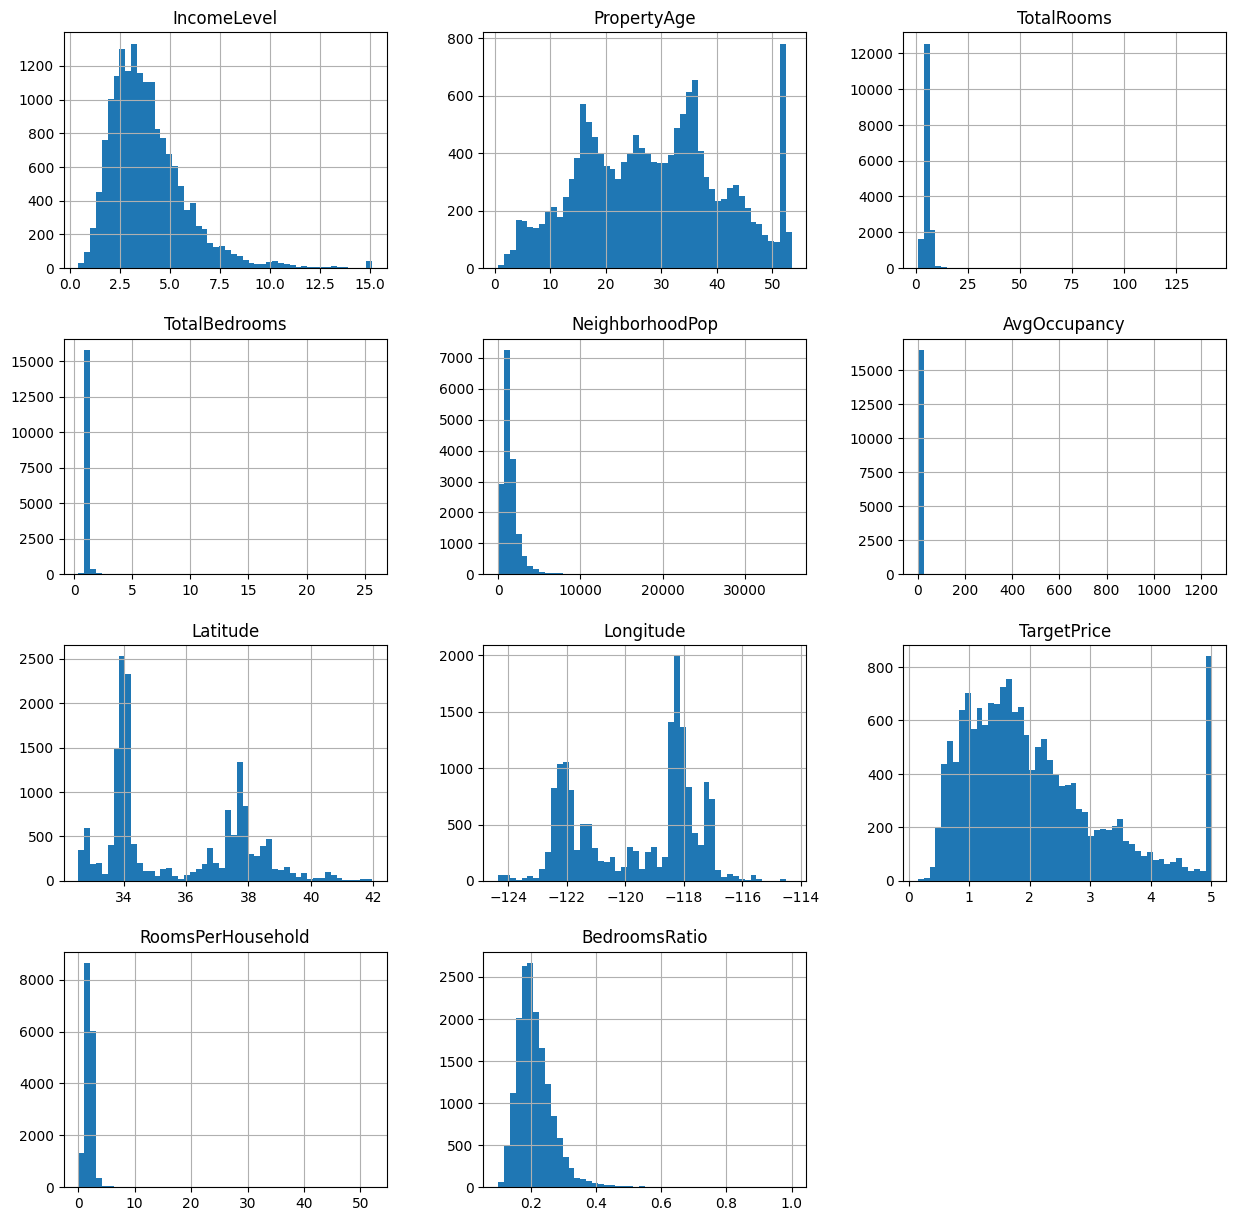

In [8]:
train_df.hist(bins=50, figsize=(15,15))
plt.show()

## Correlation Heatmap
- Visualizing the Correlation of the features across

<Axes: >

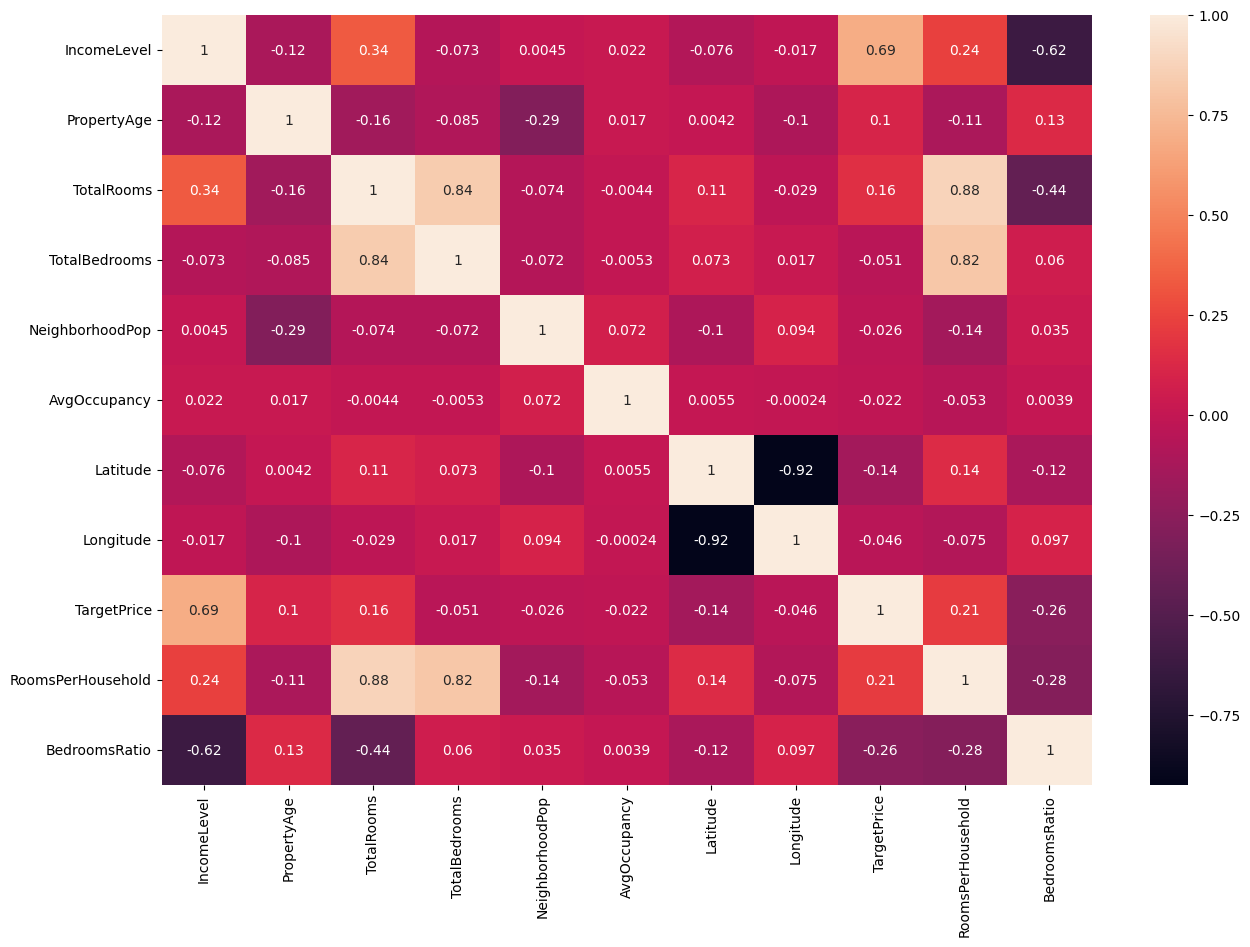

In [9]:
num_feats=train_df.drop(columns=['PropertyID'])
corr_map=num_feats.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr_map,annot=True)

## Scatterplot
- Observing the spread of the values
- Checking for possible outliers

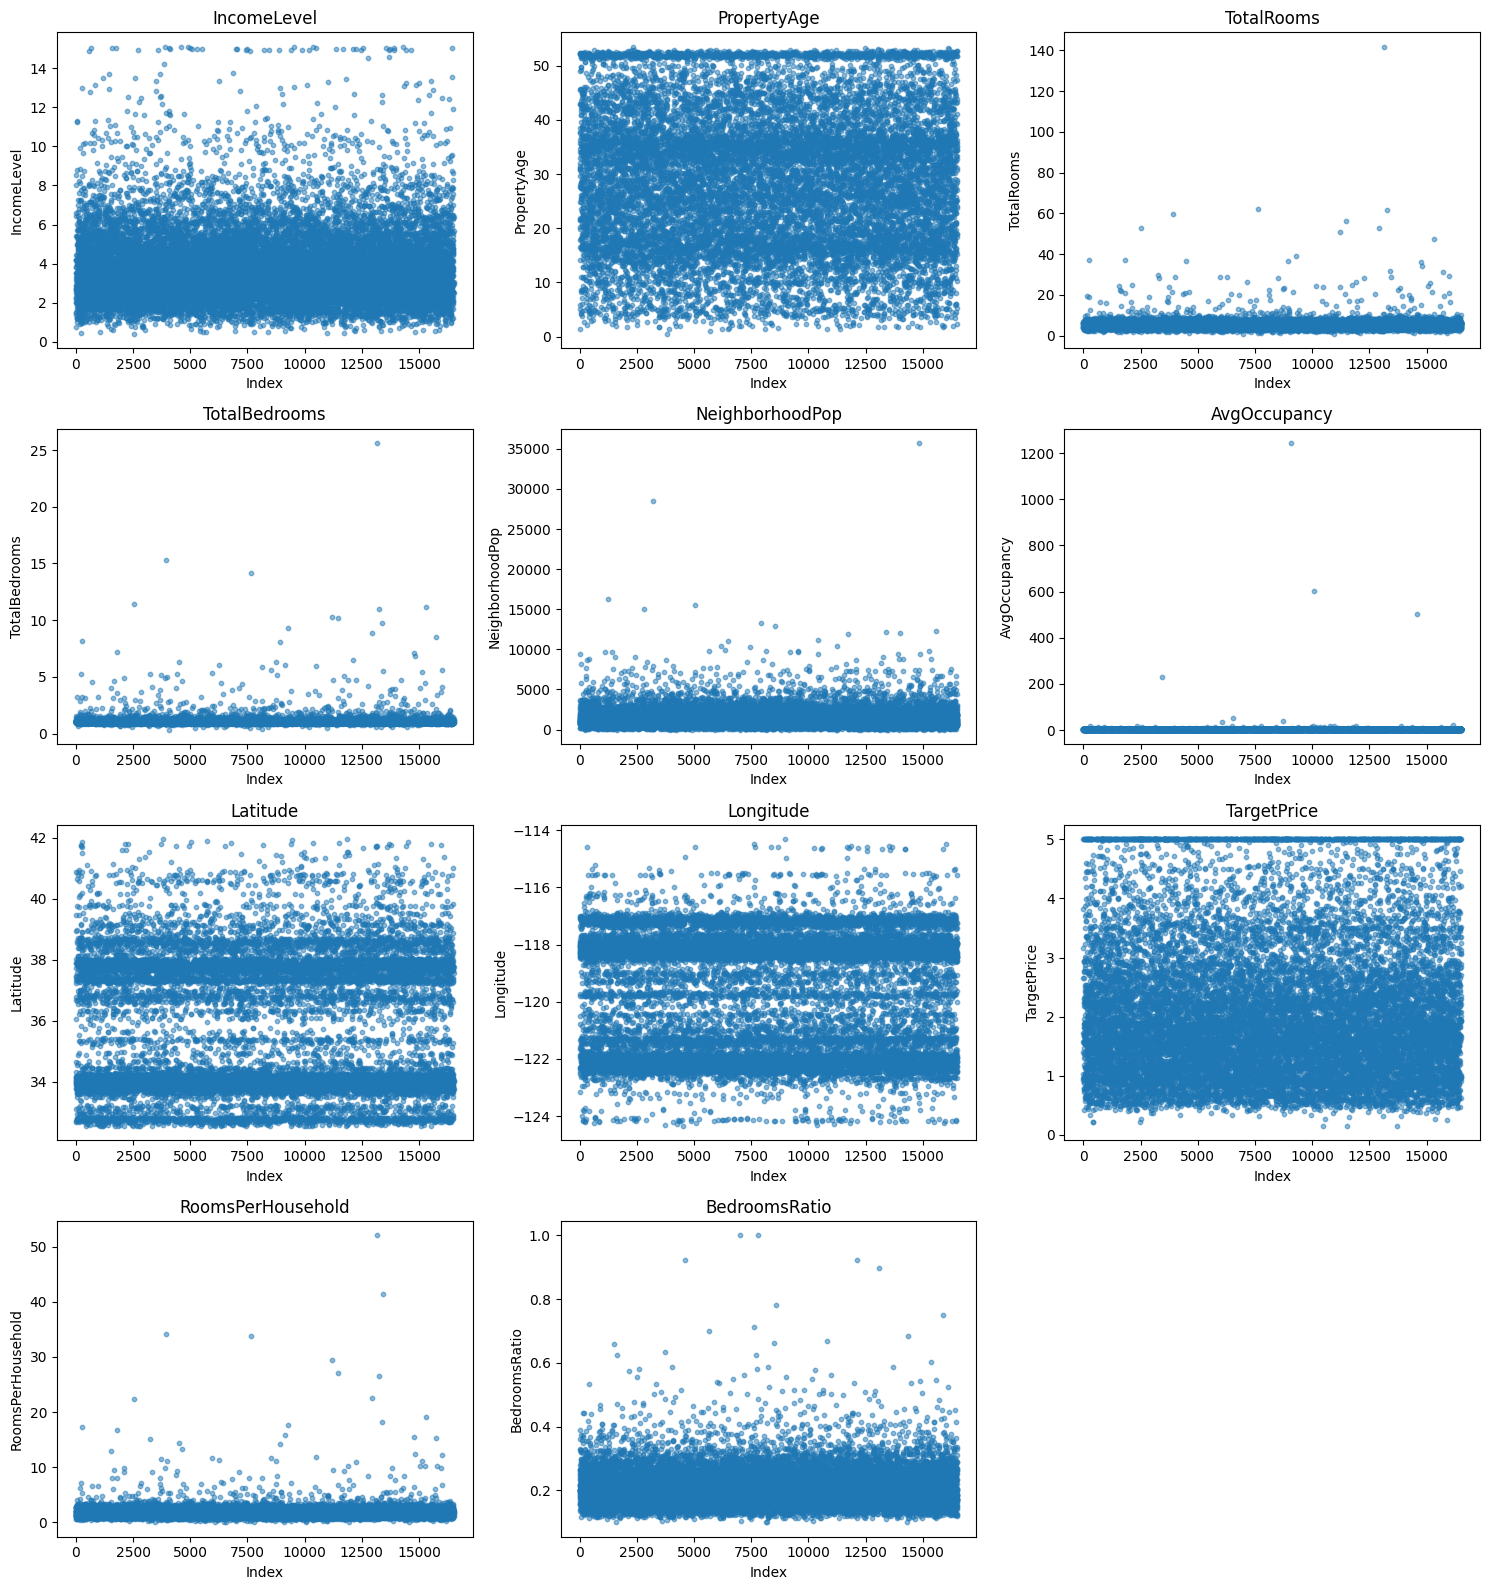

In [11]:
numeric_cols = train_df.select_dtypes(include=np.number).columns

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.scatter(train_df.index, train_df[col], alpha=0.5, s=10)
    ax.set_title(col)
    ax.set_xlabel('Index')
    ax.set_ylabel(col)

# Remove unused axes
for ax in axes[len(numeric_cols):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

# Data Preprocessing
## Feature Engineering 


In [12]:

# -----------------------------
# 2) Feature engineering
# -----------------------------
def fit_feature_stats(X):
    return {
        "lat_mean": X["Latitude"].mean(),
        "lon_mean": X["Longitude"].mean(),
    }

def add_features(X, stats):
    X = X.copy()

    # PropertyAge spike indicator
    X["PropertyAge_Capped"] = (X["PropertyAge"] >= 52).astype(int)

    # Location features
    X["dist_center"] = np.sqrt(
        (X["Latitude"] - stats["lat_mean"])**2 +
        (X["Longitude"] - stats["lon_mean"])**2
    )
    X["Lat_Long"] = X["Latitude"] * X["Longitude"]
    X["Lat2"] = X["Latitude"] ** 2
    X["Long2"] = X["Longitude"] ** 2

    # Interaction / ratio features
    X["RoomsPerBedroom"] = X["TotalRooms"] / (X["TotalBedrooms"] + 1e-6)
    X["PopPerRoom"] = X["NeighborhoodPop"] / (X["TotalRooms"] + 1e-6)
    X["Income_Rooms"] = X["IncomeLevel"] * X["RoomsPerHousehold"]
    X["Income_Pop"] = X["IncomeLevel"] * np.log1p(X["NeighborhoodPop"].clip(lower=0))

    # Skewed columns -> log1p
    skew_cols = [
        "TotalRooms",
        "TotalBedrooms",
        "NeighborhoodPop",
        "AvgOccupancy",
        "RoomsPerHousehold",
    ]
    for col in skew_cols:
        X[col] = np.log1p(X[col].clip(lower=0))

    return X

stats = fit_feature_stats(X_raw)
X = add_features(X_raw, stats)
X_test = add_features(X_test_raw, stats)

numeric_features = X.select_dtypes(include="number").columns.tolist()

## Imputing

In [13]:

# -----------------------------
# 3) Preprocessor
# -----------------------------
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features)
], remainder="drop")

# Fit preprocessing once so we can tune only the model efficiently
X_processed = preprocessor.fit_transform(X)
X_test_processed = preprocessor.transform(X_test)



# Hyperparameter Tunning

In [14]:
# -----------------------------
# 4) Hyperparameter search space
# -----------------------------
param_distributions = {
    "n_estimators": [1000, 1500, 2000, 2500, 3000, 4000, 5000],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    "max_depth": [3, 4, 5, 6, 7, 8, 9, 10],
    "min_child_weight": [1, 2, 3, 5, 7, 10],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5, 1, 2],
    "reg_alpha": [0, 0.001, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 3, 5, 10],
}

n_iter = 40
param_list = list(ParameterSampler(param_distributions, n_iter=n_iter, random_state=42))

# Cross-Validation

In [15]:
# -----------------------------
# 5) CV setup
# -----------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=42)

best_score = float("inf")
best_params = None

# -----------------------------
# 6) Manual randomized search with tqdm
# -----------------------------
for params in tqdm(param_list, desc="Tuning XGBoost"):
    fold_scores = []

    for train_idx, val_idx in kf.split(X_processed):
        X_tr, X_val = X_processed[train_idx], X_processed[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBRegressor(
            tree_method="hist",
            device="cuda",
            random_state=42,
            n_jobs=-1,
            **params
        )

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        rmse = root_mean_squared_error(y_val, preds)
        fold_scores.append(rmse)

    mean_rmse = np.mean(fold_scores)

    if mean_rmse < best_score:
        best_score = mean_rmse
        best_params = params.copy()
        tqdm.write(f"New best RMSE: {best_score:.5f} | Params: {best_params}")

print("\nBest params:", best_params)
print(f"Best CV RMSE: {best_score:.5f}")


Tuning XGBoost:   0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [08:23:34] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


New best RMSE: 0.45744 | Params: {'subsample': 0.9, 'reg_lambda': 10, 'reg_alpha': 0.01, 'n_estimators': 2500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.02, 'gamma': 0.5, 'colsample_bytree': 0.9}
New best RMSE: 0.44505 | Params: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 3000, 'min_child_weight': 2, 'max_depth': 6, 'learning_rate': 0.02, 'gamma': 0.2, 'colsample_bytree': 0.8}
New best RMSE: 0.43972 | Params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.001, 'n_estimators': 3000, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 0.6}

Best params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.001, 'n_estimators': 3000, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.02, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV RMSE: 0.43972


# Fitting the Models

In [16]:
# -----------------------------
# 7) Train final model on full data
# -----------------------------
final_model = XGBRegressor(
    tree_method="hist",
    device="cuda",
    random_state=42,
    n_jobs=-1,
    **best_params
)

final_model.fit(X_processed, y)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.02, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=-1, num_parallel_tree=None, ...)

# Prediction and Submission

In [17]:
# -----------------------------
# 8) Predict test and create submission
# -----------------------------
test_pred = final_model.predict(X_test_processed)

submission = pd.DataFrame({
    "PropertyID": test_ids,
    "TargetPrice": test_pred
})

submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
submission.head()

Saved submission.csv


,PropertyID,TargetPrice
0,PROP_20046,0.470981
1,PROP_03024,0.646765
2,PROP_15663,5.086975
3,PROP_20484,2.363340
4,PROP_09814,2.670061
